<a href="https://colab.research.google.com/github/nehajacksonb24cs2143-ctrl/road-accident-severity-prediction/blob/main/accident_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

In [ ]:
df = pd.read_csv('indian_roads_dataset.csv')

print("Dataset loaded successfully!")
print("Shape:", df.shape)

Dataset loaded successfully!
Shape: (20000, 24)


In [ ]:
df.head()
df.tail()
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 24 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   accident_id        20000 non-null  int64  
 1   city               20000 non-null  object 
 2   state              20000 non-null  object 
 3   latitude           20000 non-null  float64
 4   longitude          20000 non-null  float64
 5   date               20000 non-null  object 
 6   time               20000 non-null  object 
 7   hour               20000 non-null  int64  
 8   day_of_week        20000 non-null  object 
 9   is_weekend         20000 non-null  int64  
 10  road_type          20000 non-null  object 
 11  lanes              20000 non-null  int64  
 12  traffic_signal     20000 non-null  int64  
 13  weather            20000 non-null  object 
 14  visibility         20000 non-null  object 
 15  temperature        20000 non-null  int64  
 16  traffic_density    200

,accident_id,latitude,longitude,hour,is_weekend,lanes,traffic_signal,temperature,vehicles_involved,casualties,is_peak_hour,risk_score
count,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000
mean,9999.500000,20.389207,78.173330,11.487200,0.286150,3.493950,0.499850,27.579600,2.992000,1.726450,0.247400,0.437585
std,5773.647028,6.165791,4.485967,6.945563,0.451972,1.705406,0.500012,7.454746,1.415534,1.489104,0.431512,0.218130
min,0.000000,12.800172,72.700017,0.000000,0.000000,1.000000,0.000000,15.000000,1.000000,0.000000,0.000000,0.100000
25%,4999.750000,13.198653,73.997979,5.000000,0.000000,2.000000,0.000000,21.000000,2.000000,1.000000,0.000000,0.250000
50%,9999.500000,18.812008,77.297000,12.000000,0.000000,4.000000,0.000000,28.000000,3.000000,1.000000,0.000000,0.450000
75%,14999.250000,28.402467,80.111089,18.000000,1.000000,5.000000,1.000000,34.000000,4.000000,3.000000,0.000000,0.600000
max,19999.000000,30.799960,88.499861,23.000000,1.000000,6.000000,1.000000,40.000000,5.000000,5.000000,1.000000,1.000000


In [ ]:
missing_values = df.isnull().sum()
print(missing_values[missing_values > 0])
missing_percentage = (df.isnull().sum() / len(df) * 100).round(2)
print(missing_percentage[missing_percentage > 0])

festival    19885
dtype: int64
festival    99.42
dtype: float64


In [ ]:
df = df.drop(columns=['festival'])
print("Shape after removing festival:", df.shape)

Shape after removing festival: (20000, 23)


In [ ]:
duplicate_count = df.duplicated().sum()
print("Number of duplicate rows:", duplicate_count)
print(df.columns.tolist())

Number of duplicate rows: 0
['accident_id', 'city', 'state', 'latitude', 'longitude', 'date', 'time', 'hour', 'day_of_week', 'is_weekend', 'road_type', 'lanes', 'traffic_signal', 'weather', 'visibility', 'temperature', 'traffic_density', 'cause', 'accident_severity', 'vehicles_involved', 'casualties', 'is_peak_hour', 'risk_score']


In [ ]:
categorical_columns = df.select_dtypes(include='object').columns
for column in categorical_columns:
    print("\n", column)
    print(df[column].unique())


 city
['Pune' 'Mumbai' 'Chandigarh' 'Chennai' 'Delhi' 'Bangalore' 'Hyderabad'
 'Kolkata']

 state
['Maharashtra' 'Punjab' 'Tamil Nadu' 'Delhi' 'Karnataka' 'Telangana'
 'West Bengal']

 date
['2023-10-22' '2023-05-21' '2024-07-10' ... '2024-07-15' '2023-02-21'
 '2024-04-03']

 time
['5:00' '4:00' '13:00' '11:00' '16:00' '8:00' '6:00' '14:00' '3:00' '2:00'
 '9:00' '18:00' '21:00' '1:00' '0:00' '23:00' '17:00' '7:00' '22:00'
 '15:00' '10:00' '19:00' '12:00' '20:00']

 day_of_week
['Sunday' 'Wednesday' 'Thursday' 'Monday' 'Friday' 'Tuesday' 'Saturday']

 road_type
['highway' 'urban' 'rural']

 weather
['fog' 'clear' 'rain']

 visibility
['low' 'high' 'medium']

 traffic_density
['high' 'low' 'medium']

 cause
['weather' 'distraction' 'overspeeding' 'drunk driving' 'poor road']

 accident_severity
['fatal' 'major' 'minor']


In [ ]:
severity_counts = df['accident_severity'].value_counts()
print(severity_counts)
severity_percentage = (
    df['accident_severity']
    .value_counts(normalize=True) * 100
).round(2)
print(severity_percentage)

accident_severity
minor    11025
major     5988
fatal     2987
Name: count, dtype: int64
accident_severity
minor    55.12
major    29.94
fatal    14.94
Name: proportion, dtype: float64


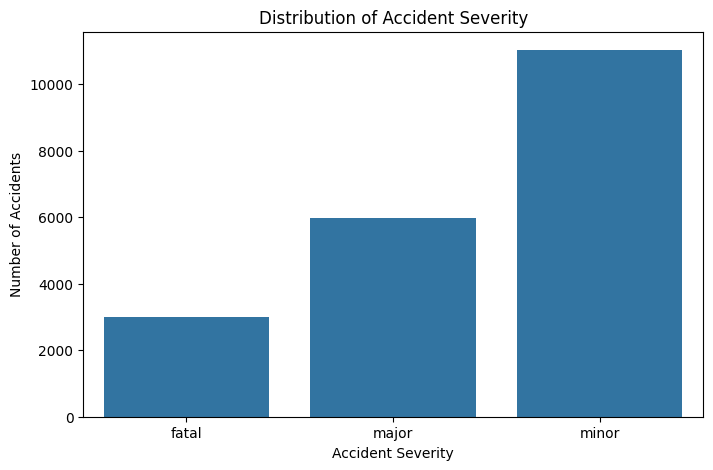

In [ ]:
plt.figure(figsize=(8, 5))
sns.countplot(
    data=df,
    x='accident_severity'
)
plt.title('Distribution of Accident Severity')
plt.xlabel('Accident Severity')
plt.ylabel('Number of Accidents')

plt.show()

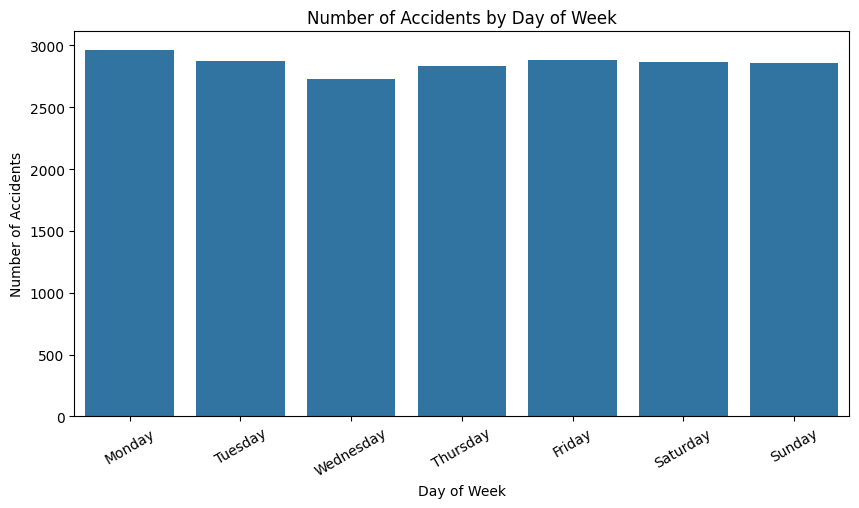

In [ ]:
plt.figure(figsize=(10, 5))
sns.countplot(
    data=df,
    x='day_of_week',
    order=[
        'Monday',
        'Tuesday',
        'Wednesday',
        'Thursday',
        'Friday',
        'Saturday',
        'Sunday'
    ]
)

plt.title('Number of Accidents by Day of Week')
plt.xlabel('Day of Week')
plt.ylabel('Number of Accidents')
plt.xticks(rotation=30)

plt.show()

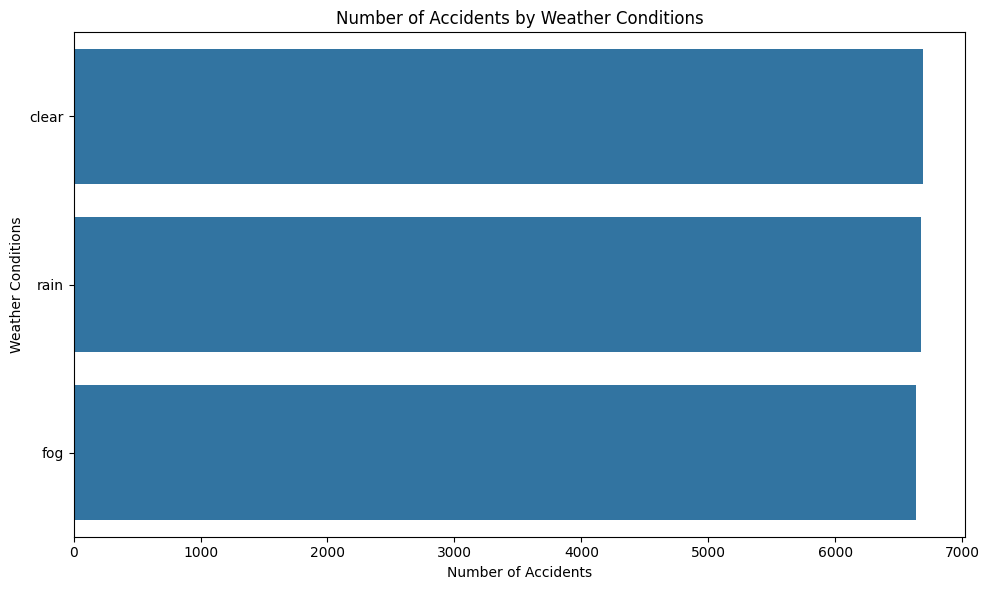

In [ ]:
plt.figure(figsize=(10, 6))

weather_counts = df['weather'].value_counts()

sns.barplot(
    x=weather_counts.values,
    y=weather_counts.index
)

plt.title('Number of Accidents by Weather Conditions')
plt.xlabel('Number of Accidents')
plt.ylabel('Weather Conditions')

plt.tight_layout()
plt.show()

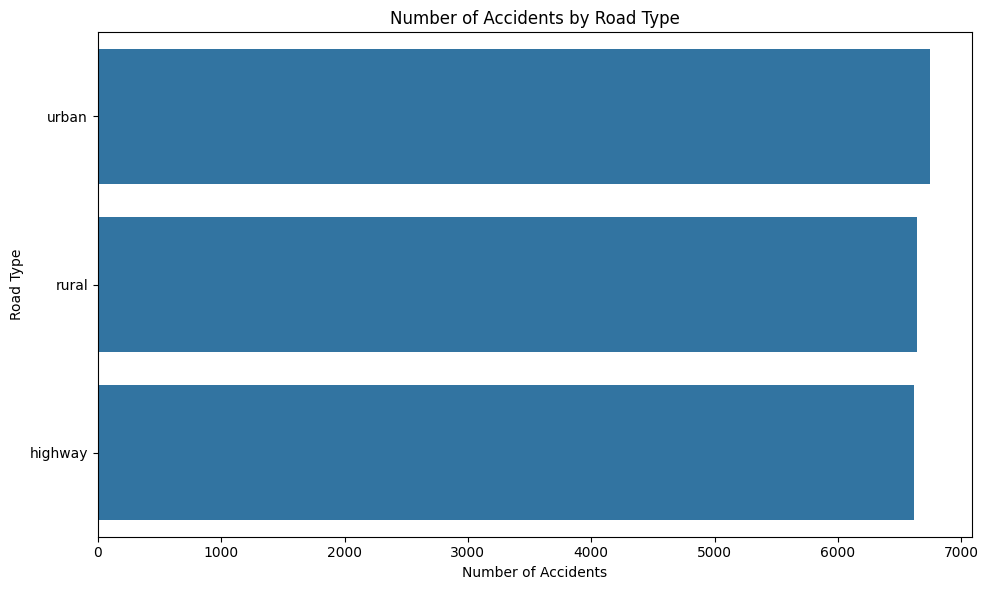

In [ ]:
plt.figure(figsize=(10, 6))
road_counts = df['road_type'].value_counts()
sns.barplot(
    x=road_counts.values,
    y=road_counts.index
)

plt.title('Number of Accidents by Road Type')
plt.xlabel('Number of Accidents')
plt.ylabel('Road Type')

plt.tight_layout()
plt.show()

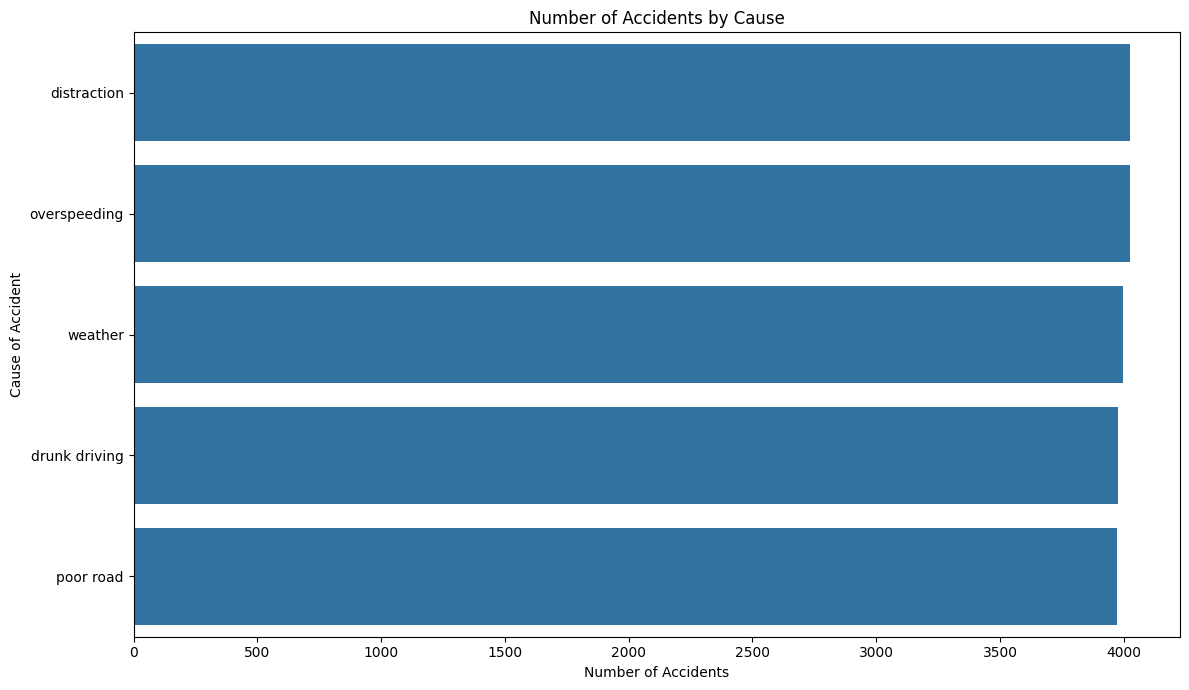

In [ ]:
plt.figure(figsize=(12, 7))
cause_counts = df['cause'].value_counts()
sns.barplot(
    x=cause_counts.values,
    y=cause_counts.index
)

plt.title('Number of Accidents by Cause')
plt.xlabel('Number of Accidents')
plt.ylabel('Cause of Accident')

plt.tight_layout()
plt.show()

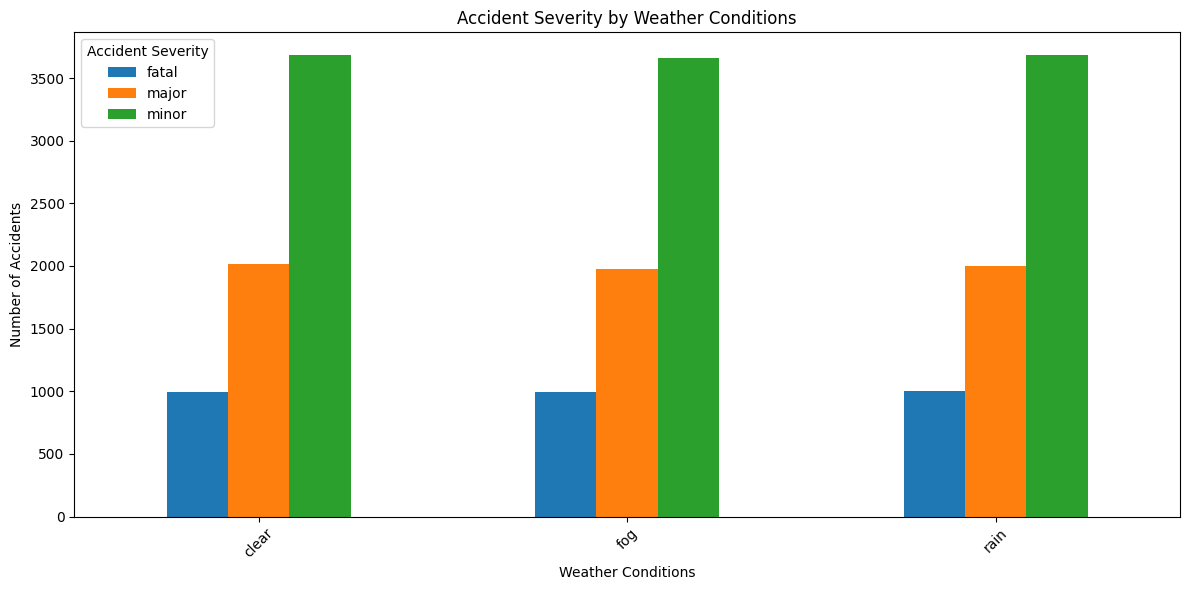

In [ ]:
severity_weather = pd.crosstab(
    df['weather'],
    df['accident_severity']
)

severity_weather.plot(
    kind='bar',
    figsize=(12, 6)
)

plt.title('Accident Severity by Weather Conditions')
plt.xlabel('Weather Conditions')
plt.ylabel('Number of Accidents')
plt.xticks(rotation=45)
plt.legend(title='Accident Severity')

plt.tight_layout()
plt.show()

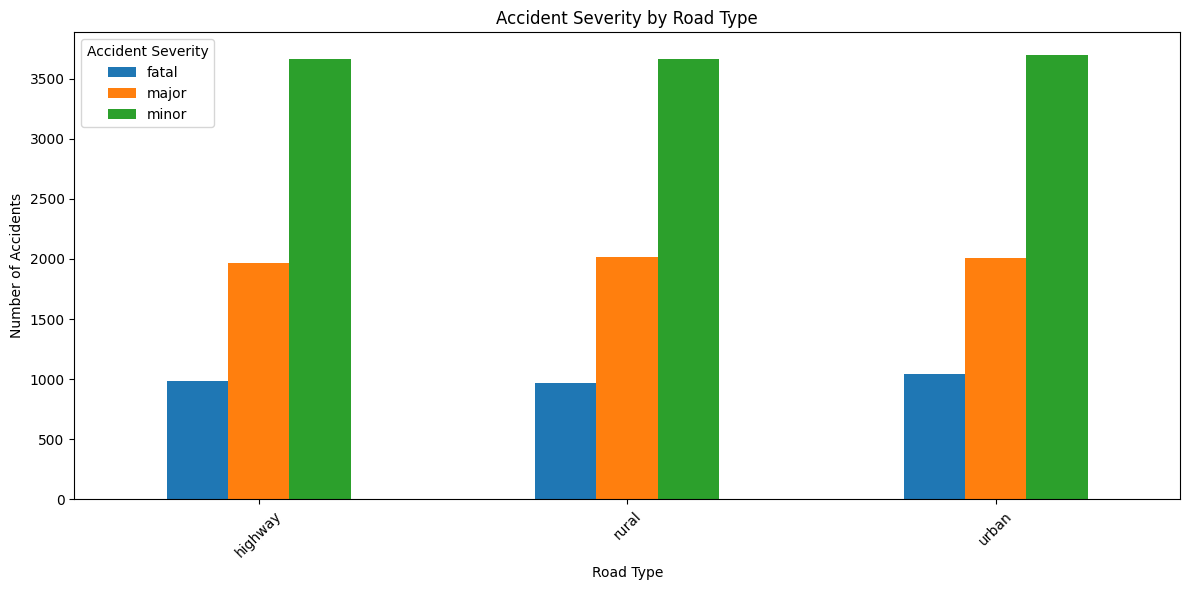

In [ ]:
severity_road = pd.crosstab(
    df['road_type'],
    df['accident_severity']
)

severity_road.plot(
    kind='bar',
    figsize=(12, 6)
)

plt.title('Accident Severity by Road Type')
plt.xlabel('Road Type')
plt.ylabel('Number of Accidents')
plt.xticks(rotation=45)
plt.legend(title='Accident Severity')

plt.tight_layout()
plt.show()

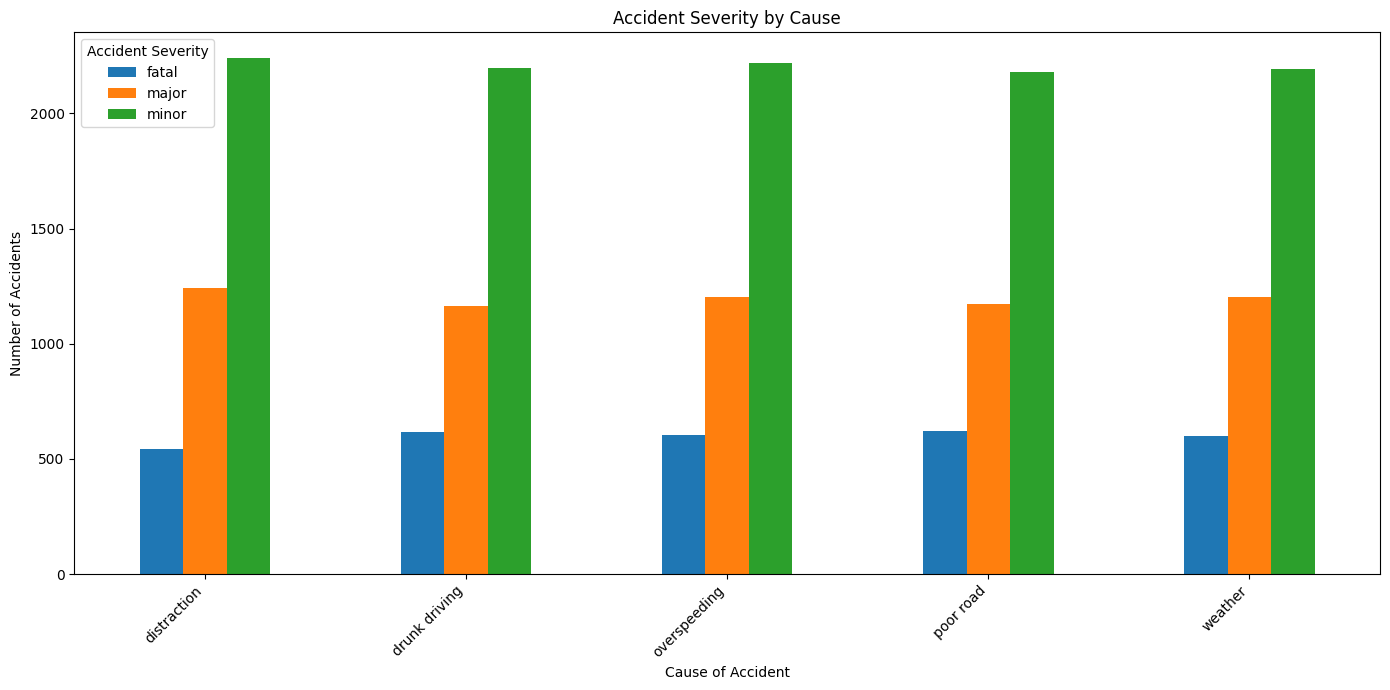

In [ ]:
severity_cause = pd.crosstab(
    df['cause'],
    df['accident_severity']
)

severity_cause.plot(
    kind='bar',
    figsize=(14, 7)
)

plt.title('Accident Severity by Cause')
plt.xlabel('Cause of Accident')
plt.ylabel('Number of Accidents')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Accident Severity')

plt.tight_layout()
plt.show()

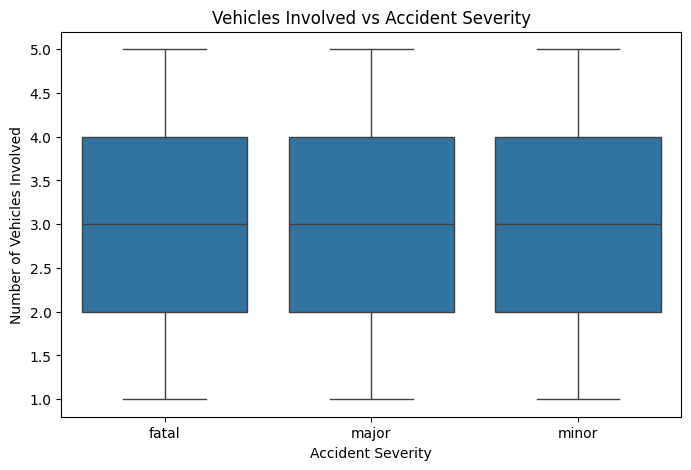

In [ ]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x='accident_severity',
    y='vehicles_involved'
)

plt.title('Vehicles Involved vs Accident Severity')
plt.xlabel('Accident Severity')
plt.ylabel('Number of Vehicles Involved')

plt.show()

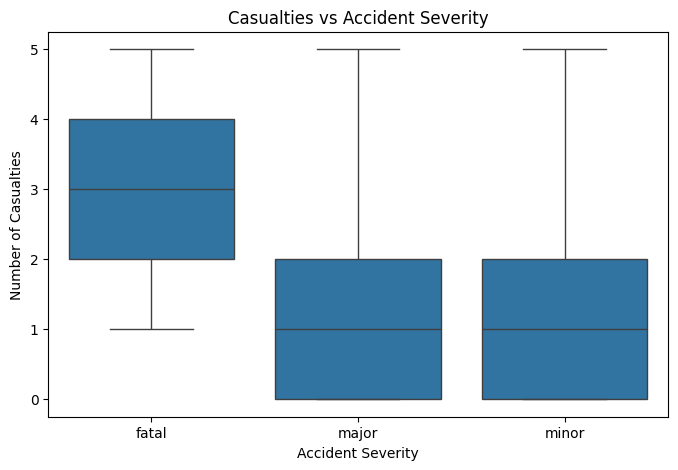

In [ ]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x='accident_severity',
    y='casualties'
)

plt.title('Casualties vs Accident Severity')
plt.xlabel('Accident Severity')
plt.ylabel('Number of Casualties')

plt.show()

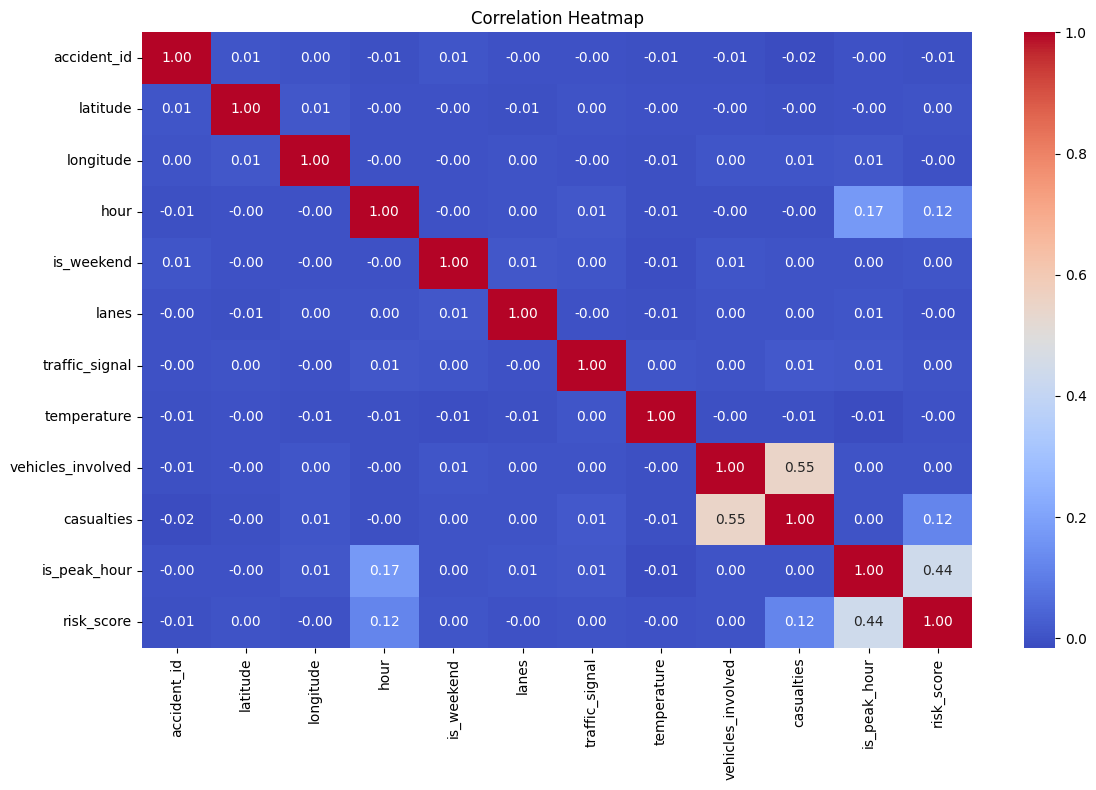

In [ ]:
numeric_columns = df.select_dtypes(
    include=['int64', 'float64']
)

plt.figure(figsize=(12, 8))

sns.heatmap(
    numeric_columns.corr(),
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Correlation Heatmap')

plt.tight_layout()
plt.show()

In [ ]:
print(df['risk_score'].describe())

print("\nCorrelation with numerical variables:")
print(df.select_dtypes(include=['int64', 'float64']).corr()['risk_score'].sort_values(ascending=False))

count    20000.000000
mean         0.437585
std          0.218130
min          0.100000
25%          0.250000
50%          0.450000
75%          0.600000
max          1.000000
Name: risk_score, dtype: float64

Correlation with numerical variables:
risk_score           1.000000
is_peak_hour         0.436848
hour                 0.122017
casualties           0.119954
is_weekend           0.004033
traffic_signal       0.001817
latitude             0.001459
vehicles_involved    0.000642
longitude           -0.001439
lanes               -0.001721
temperature         -0.001885
accident_id         -0.005487
Name: risk_score, dtype: float64


In [ ]:
print(
    df.groupby('accident_severity')['risk_score']
      .agg(['count', 'mean', 'min', 'max'])
)

                   count      mean  min  max
accident_severity                           
fatal               2987  0.607516  0.3  1.0
major               5988  0.406847  0.1  0.9
minor              11025  0.408240  0.1  0.9


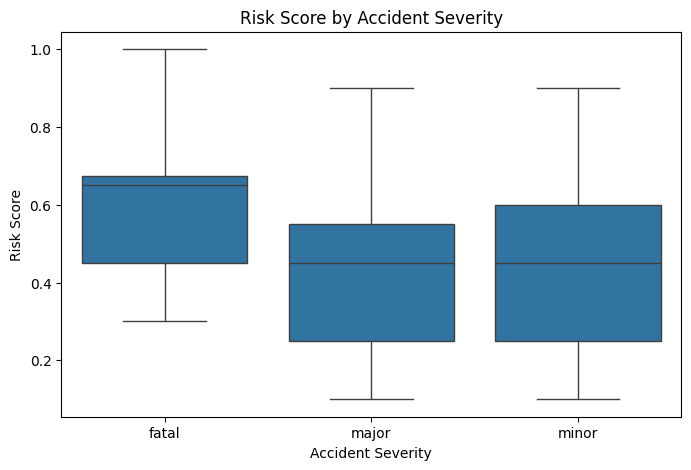

In [ ]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x='accident_severity',
    y='risk_score'
)

plt.title('Risk Score by Accident Severity')
plt.xlabel('Accident Severity')
plt.ylabel('Risk Score')

plt.show()

In [ ]:
X = df.drop(columns=['accident_severity'])
y = df['accident_severity']

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (20000, 22)
y shape: (20000,)


In [ ]:
X = X.drop(columns=['accident_id', 'date', 'time'])

print("Shape after removing unnecessary columns:", X.shape)

Shape after removing unnecessary columns: (20000, 19)


In [ ]:
categorical_columns = X.select_dtypes(include='object').columns

print("Categorical columns:")
print(categorical_columns)
X = pd.get_dummies(
    X,
    columns=categorical_columns,
    drop_first=True
)

print("Shape after encoding:", X.shape)

Categorical columns:
Index(['city', 'state', 'day_of_week', 'road_type', 'weather', 'visibility',
       'traffic_density', 'cause'],
      dtype='object')
Shape after encoding: (20000, 42)


In [ ]:
print(X.head())

    latitude  longitude  hour  is_weekend  lanes  traffic_signal  temperature  \
0  18.680827  73.930388     5           1      3               1           32   
1  18.817732  72.790846     4           1      4               0           34   
2  19.096889  72.819424    13           0      3               0           21   
3  30.787805  76.847507    11           1      1               1           30   
4  12.965155  80.283313    16           0      3               1           24   

   vehicles_involved  casualties  is_peak_hour  ...  weather_fog  \
0                  2           2             0  ...         True   
1                  4           3             0  ...        False   
2                  1           1             0  ...         True   
3                  5           2             0  ...         True   
4                  2           1             0  ...        False   

   weather_rain  visibility_low  visibility_medium  traffic_density_low  \
0         False            Tr

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (16000, 42)
Testing data: (4000, 42)


In [ ]:
logistic_model = LogisticRegression(
    max_iter=1000,
    class_weight='balanced'
)

logistic_model.fit(X_train, y_train)

y_pred_lr = logistic_model.predict(X_test)

accuracy_lr = accuracy_score(y_test, y_pred_lr)

print("Logistic Regression Accuracy:",
      round(accuracy_lr * 100, 2), "%")

print("\nClassification Report:")
print(classification_report(y_test, y_pred_lr))

Logistic Regression Accuracy: 57.38 %

Classification Report:
              precision    recall  f1-score   support

       fatal       0.99      1.00      1.00       597
       major       0.35      0.48      0.40      1198
       minor       0.64      0.51      0.57      2205

    accuracy                           0.57      4000
   macro avg       0.66      0.66      0.66      4000
weighted avg       0.61      0.57      0.58      4000



/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


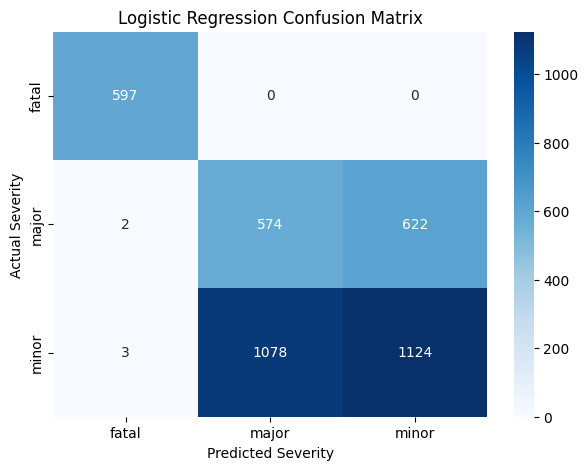

In [ ]:
cm_lr = confusion_matrix(y_test, y_pred_lr)

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm_lr,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=logistic_model.classes_,
    yticklabels=logistic_model.classes_
)

plt.title('Logistic Regression Confusion Matrix')
plt.xlabel('Predicted Severity')
plt.ylabel('Actual Severity')

plt.show()

In [ ]:
dt_model = DecisionTreeClassifier(
    random_state=42,
    class_weight='balanced'
)

dt_model.fit(X_train, y_train)

y_pred_dt = dt_model.predict(X_test)

accuracy_dt = accuracy_score(y_test, y_pred_dt)

print("Decision Tree Accuracy:",
      round(accuracy_dt * 100, 2), "%")

print("\nClassification Report:")
print(classification_report(y_test, y_pred_dt))

Decision Tree Accuracy: 60.55 %

Classification Report:
              precision    recall  f1-score   support

       fatal       0.99      0.99      0.99       597
       major       0.34      0.34      0.34      1198
       minor       0.64      0.65      0.64      2205

    accuracy                           0.61      4000
   macro avg       0.66      0.66      0.66      4000
weighted avg       0.60      0.61      0.60      4000



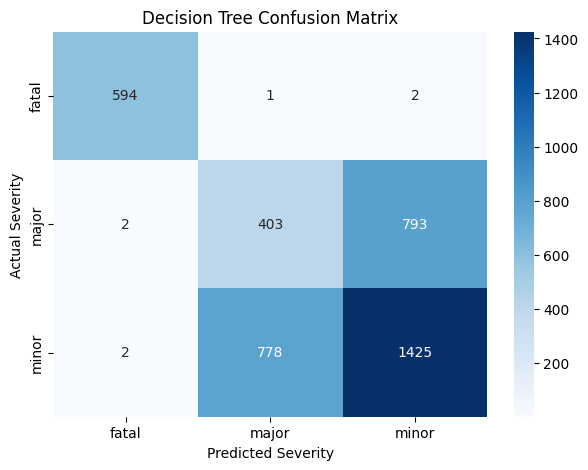

In [ ]:
cm_dt = confusion_matrix(y_test, y_pred_dt)

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm_dt,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=dt_model.classes_,
    yticklabels=dt_model.classes_
)

plt.title('Decision Tree Confusion Matrix')
plt.xlabel('Predicted Severity')
plt.ylabel('Actual Severity')

plt.show()

In [ ]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight='balanced'
)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

accuracy_rf = accuracy_score(y_test, y_pred_rf)

print("Random Forest Accuracy:",
      round(accuracy_rf * 100, 2), "%")

print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))

Random Forest Accuracy: 68.23 %

Classification Report:
              precision    recall  f1-score   support

       fatal       0.99      0.95      0.97       597
       major       0.37      0.05      0.09      1198
       minor       0.64      0.95      0.77      2205

    accuracy                           0.68      4000
   macro avg       0.67      0.65      0.61      4000
weighted avg       0.61      0.68      0.59      4000



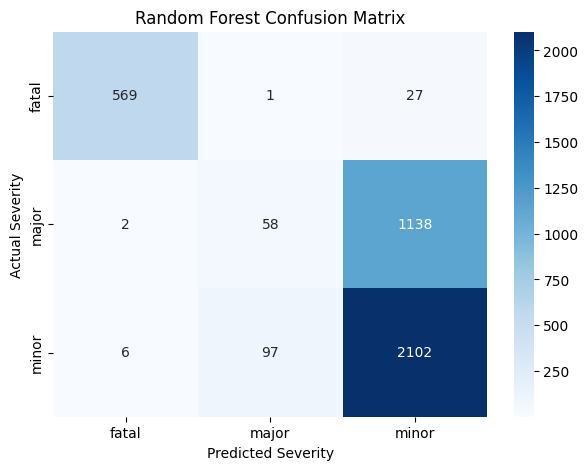

In [ ]:
cm_rf = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm_rf,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=rf_model.classes_,
    yticklabels=rf_model.classes_
)

plt.title('Random Forest Confusion Matrix')
plt.xlabel('Predicted Severity')
plt.ylabel('Actual Severity')

plt.show()

In [ ]:
results = pd.DataFrame({
    'Model': [
        'Logistic Regression',
        'Decision Tree',
        'Random Forest'
    ],
    'Accuracy': [
        accuracy_lr,
        accuracy_dt,
        accuracy_rf
    ]
})

results['Accuracy'] = (results['Accuracy'] * 100).round(2)

print(results)

                 Model  Accuracy
0  Logistic Regression     57.38
1        Decision Tree     60.55
2        Random Forest     68.23


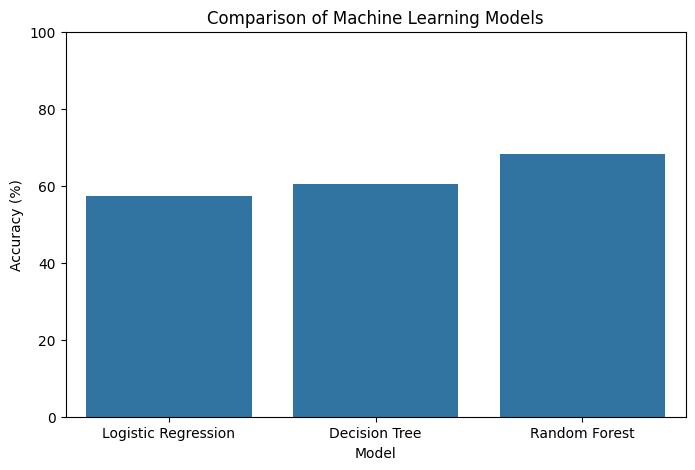

In [ ]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=results,
    x='Model',
    y='Accuracy'
)

plt.title('Comparison of Machine Learning Models')
plt.xlabel('Model')
plt.ylabel('Accuracy (%)')
plt.ylim(0, 100)

plt.show()

In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score

comparison = pd.DataFrame({
    'Model': [
        'Logistic Regression',
        'Decision Tree',
        'Random Forest'
    ],
    'Accuracy': [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_dt),
        accuracy_score(y_test, y_pred_rf)
    ],
    'Precision': [
        precision_score(y_test, y_pred_lr, average='weighted'),
        precision_score(y_test, y_pred_dt, average='weighted'),
        precision_score(y_test, y_pred_rf, average='weighted')
    ],
    'Recall': [
        recall_score(y_test, y_pred_lr, average='weighted'),
        recall_score(y_test, y_pred_dt, average='weighted'),
        recall_score(y_test, y_pred_rf, average='weighted')
    ],
    'F1-Score': [
        f1_score(y_test, y_pred_lr, average='weighted'),
        f1_score(y_test, y_pred_dt, average='weighted'),
        f1_score(y_test, y_pred_rf, average='weighted')
    ]
})

comparison.iloc[:, 1:] = (comparison.iloc[:, 1:] * 100).round(2)

print(comparison)

                 Model  Accuracy  Precision  Recall  F1-Score
0  Logistic Regression     57.38      60.69   57.38     58.29
1        Decision Tree     60.55      60.42   60.55     60.48
2        Random Forest     68.23      61.32   68.23     59.38


In [ ]:
feature_importance = pd.Series(
    rf_model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

print("Top 10 Important Features:")
print(feature_importance.head(10))

Top 10 Important Features:
risk_score                0.164052
casualties                0.101853
latitude                  0.079803
longitude                 0.078687
temperature               0.067151
hour                      0.064052
vehicles_involved         0.051106
lanes                     0.041578
traffic_density_low       0.033200
traffic_density_medium    0.029916
dtype: float64


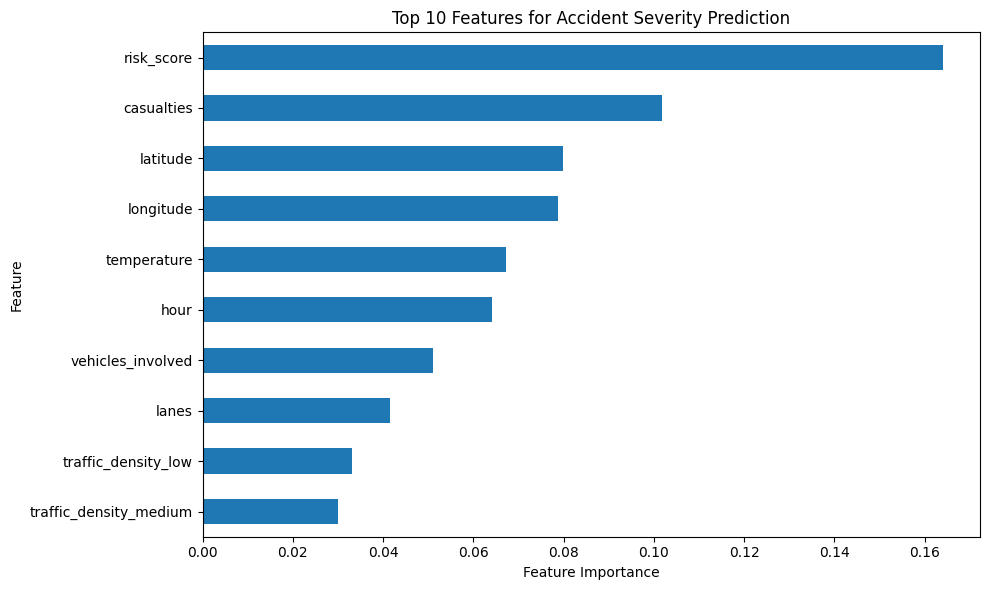

In [ ]:
plt.figure(figsize=(10, 6))

feature_importance.head(10).sort_values().plot(
    kind='barh'
)

plt.title('Top 10 Features for Accident Severity Prediction')
plt.xlabel('Feature Importance')
plt.ylabel('Feature')

plt.tight_layout()
plt.show()

In [ ]:
print("FINAL MODEL COMPARISON")
print(comparison)

FINAL MODEL COMPARISON
                 Model  Accuracy  Precision  Recall  F1-Score
0  Logistic Regression     57.38      60.69   57.38     58.29
1        Decision Tree     60.55      60.42   60.55     60.48
2        Random Forest     68.23      61.32   68.23     59.38


In [ ]:
best_model = comparison.loc[
    comparison['F1-Score'].idxmax()
]

print("Best Performing Model:")
print(best_model)

Best Performing Model:
Model        Decision Tree
Accuracy             60.55
Precision            60.42
Recall               60.55
F1-Score             60.48
Name: 1, dtype: object


In [ ]:
top_features = feature_importance.head(10)

print("Top 10 Important Features:")
print(top_features)

Top 10 Important Features:
risk_score                0.164052
casualties                0.101853
latitude                  0.079803
longitude                 0.078687
temperature               0.067151
hour                      0.064052
vehicles_involved         0.051106
lanes                     0.041578
traffic_density_low       0.033200
traffic_density_medium    0.029916
dtype: float64


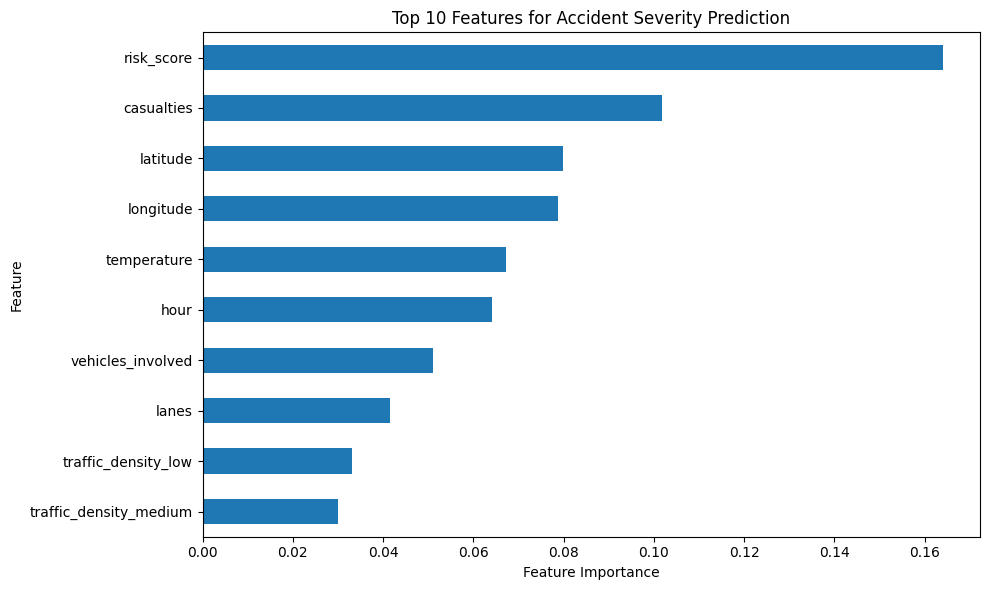

In [ ]:
plt.figure(figsize=(10, 6))

top_features.sort_values().plot(kind='barh')

plt.title('Top 10 Features for Accident Severity Prediction')
plt.xlabel('Feature Importance')
plt.ylabel('Feature')

plt.tight_layout()
plt.show()

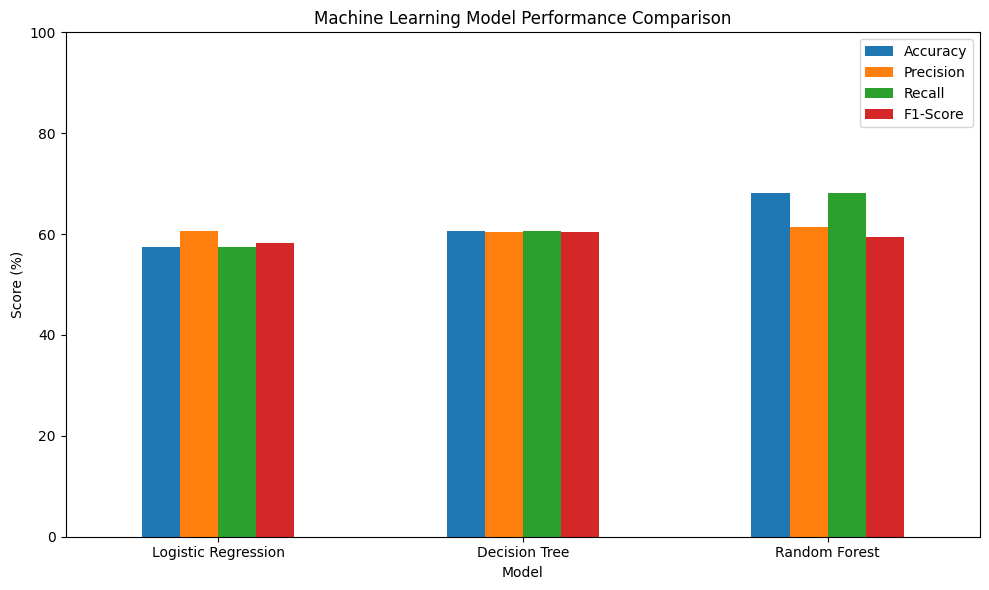

In [ ]:
comparison_plot = comparison.set_index('Model')

comparison_plot[['Accuracy', 'Precision', 'Recall', 'F1-Score']].plot(
    kind='bar',
    figsize=(10, 6)
)

plt.title('Machine Learning Model Performance Comparison')
plt.xlabel('Model')
plt.ylabel('Score (%)')
plt.ylim(0, 100)
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

In [ ]:
print("=== LOGISTIC REGRESSION ===")
print(classification_report(y_test, y_pred_lr))

print("\n=== DECISION TREE ===")
print(classification_report(y_test, y_pred_dt))

print("\n=== RANDOM FOREST ===")
print(classification_report(y_test, y_pred_rf))

=== LOGISTIC REGRESSION ===
              precision    recall  f1-score   support

       fatal       0.99      1.00      1.00       597
       major       0.35      0.48      0.40      1198
       minor       0.64      0.51      0.57      2205

    accuracy                           0.57      4000
   macro avg       0.66      0.66      0.66      4000
weighted avg       0.61      0.57      0.58      4000


=== DECISION TREE ===
              precision    recall  f1-score   support

       fatal       0.99      0.99      0.99       597
       major       0.34      0.34      0.34      1198
       minor       0.64      0.65      0.64      2205

    accuracy                           0.61      4000
   macro avg       0.66      0.66      0.66      4000
weighted avg       0.60      0.61      0.60      4000


=== RANDOM FOREST ===
              precision    recall  f1-score   support

       fatal       0.99      0.95      0.97       597
       major       0.37      0.05      0.09      1198
 

In [ ]:
final_results = comparison.copy()

print("Final Model Performance:")
print(final_results)

Final Model Performance:
                 Model  Accuracy  Precision  Recall  F1-Score
0  Logistic Regression     57.38      60.69   57.38     58.29
1        Decision Tree     60.55      60.42   60.55     60.48
2        Random Forest     68.23      61.32   68.23     59.38


In [ ]:
best_model_name = comparison.loc[
    comparison['F1-Score'].idxmax(), 'Model'
]

best_f1 = comparison['F1-Score'].max()

print("Best Model:", best_model_name)
print("F1-Score:", best_f1, "%")

Best Model: Decision Tree
F1-Score: 60.48 %


In [ ]:
best_accuracy = comparison.loc[
    comparison['Model'] == best_model_name,
    'Accuracy'
].values[0]

print("Best Model Accuracy:", best_accuracy, "%")

Best Model Accuracy: 60.55 %


In [ ]:
if best_model_name == 'Logistic Regression':
    best_predictions = y_pred_lr
    best_model = logistic_model

elif best_model_name == 'Decision Tree':
    best_predictions = y_pred_dt
    best_model = dt_model

else:
    best_predictions = y_pred_rf
    best_model = rf_model

print("Selected Model:", best_model_name)

Selected Model: Decision Tree


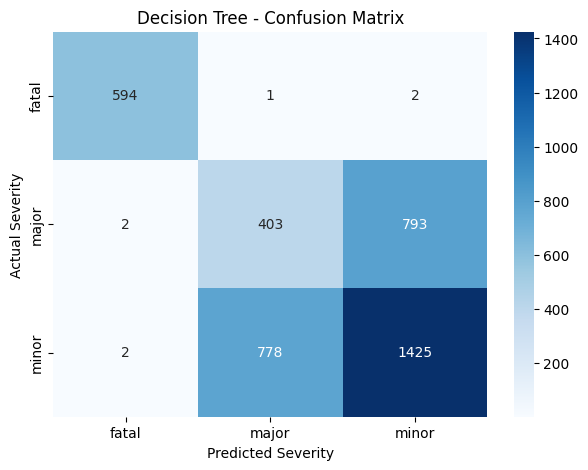

In [ ]:
cm_best = confusion_matrix(y_test, best_predictions)

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm_best,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=best_model.classes_,
    yticklabels=best_model.classes_
)

plt.title(f'{best_model_name} - Confusion Matrix')
plt.xlabel('Predicted Severity')
plt.ylabel('Actual Severity')

plt.show()

In [ ]:
print(f"Classification Report - {best_model_name}")
print(
    classification_report(
        y_test,
        best_predictions
    )
)

Classification Report - Decision Tree
              precision    recall  f1-score   support

       fatal       0.99      0.99      0.99       597
       major       0.34      0.34      0.34      1198
       minor       0.64      0.65      0.64      2205

    accuracy                           0.61      4000
   macro avg       0.66      0.66      0.66      4000
weighted avg       0.60      0.61      0.60      4000



In [ ]:
print("Actual Class Distribution:")
print(y_test.value_counts())

print("\nPredicted Class Distribution:")
print(pd.Series(best_predictions).value_counts())

Actual Class Distribution:
accident_severity
minor    2205
major    1198
fatal     597
Name: count, dtype: int64

Predicted Class Distribution:
minor    2220
major    1182
fatal     598
Name: count, dtype: int64


In [ ]:
comparison.to_csv(
    'model_comparison.csv',
    index=False
)

print("Model comparison saved successfully.")

Model comparison saved successfully.


In [ ]:
top_10_features = feature_importance.head(10).reset_index()

top_10_features.columns = [
    'Feature',
    'Importance'
]

print(top_10_features)
top_10_features.to_csv(
    'top_10_features.csv',
    index=False
)

print("Top 10 features saved successfully.")

                  Feature  Importance
0              risk_score    0.164052
1              casualties    0.101853
2                latitude    0.079803
3               longitude    0.078687
4             temperature    0.067151
5                    hour    0.064052
6       vehicles_involved    0.051106
7                   lanes    0.041578
8     traffic_density_low    0.033200
9  traffic_density_medium    0.029916
Top 10 features saved successfully.


In [ ]:
# Step 53 — Create a new accident record

new_accident = pd.DataFrame({
    'city': ['Trivandrum'],
    'state': ['Kerala'],
    'day_of_week': ['Monday'],
    'road_type': ['Urban'],
    'weather': ['Clear'],
    'visibility': ['Good'],
    'traffic_density': ['High'],
    'cause': ['Speeding'],
    'hour': [18],
    'is_weekend': [0]
})

print(new_accident)
print(X.columns.tolist())

         city   state day_of_week road_type weather visibility  \
0  Trivandrum  Kerala      Monday     Urban   Clear       Good   

  traffic_density     cause  hour  is_weekend  
0            High  Speeding    18           0  
['latitude', 'longitude', 'hour', 'is_weekend', 'lanes', 'traffic_signal', 'temperature', 'vehicles_involved', 'casualties', 'is_peak_hour', 'risk_score', 'city_Chandigarh', 'city_Chennai', 'city_Delhi', 'city_Hyderabad', 'city_Kolkata', 'city_Mumbai', 'city_Pune', 'state_Karnataka', 'state_Maharashtra', 'state_Punjab', 'state_Tamil Nadu', 'state_Telangana', 'state_West Bengal', 'day_of_week_Monday', 'day_of_week_Saturday', 'day_of_week_Sunday', 'day_of_week_Thursday', 'day_of_week_Tuesday', 'day_of_week_Wednesday', 'road_type_rural', 'road_type_urban', 'weather_fog', 'weather_rain', 'visibility_low', 'visibility_medium', 'traffic_density_low', 'traffic_density_medium', 'cause_drunk driving', 'cause_overspeeding', 'cause_poor road', 'cause_weather']


In [ ]:
new_accident_encoded = pd.get_dummies(
    new_accident,
    drop_first=True
)

print(new_accident_encoded)
new_accident_encoded = new_accident_encoded.reindex(
    columns=X.columns,
    fill_value=0
)

print("New accident data shape:", new_accident_encoded.shape)
print("Training feature count:", X.shape[1])
print("New accident feature count:", new_accident_encoded.shape[1])

   hour  is_weekend
0    18           0
New accident data shape: (1, 42)
Training feature count: 42
New accident feature count: 42


In [ ]:
prediction = best_model.predict(new_accident_encoded)
print("Predicted Accident Severity:", prediction[0])

Predicted Accident Severity: minor


In [ ]:
probabilities = best_model.predict_proba(
    new_accident_encoded
)[0]

for class_name, probability in zip(
    best_model.classes_,
    probabilities
):
    print(
        class_name,
        ":",
        round(probability * 100, 2),
        "%"
    )

fatal : 0.0 %
major : 0.0 %
minor : 100.0 %


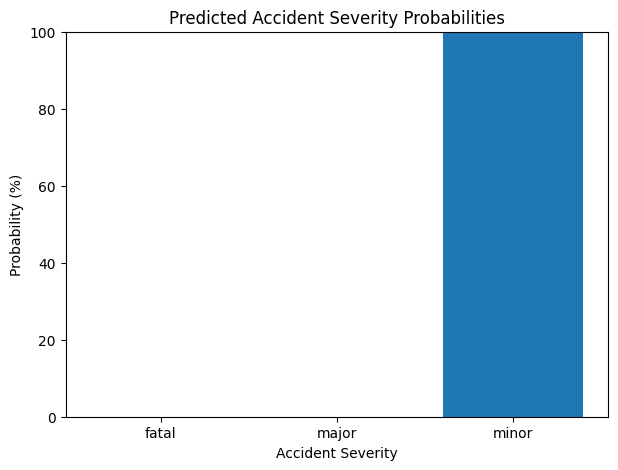

In [ ]:
plt.figure(figsize=(7, 5))

plt.bar(
    best_model.classes_,
    probabilities * 100
)

plt.title('Predicted Accident Severity Probabilities')
plt.xlabel('Accident Severity')
plt.ylabel('Probability (%)')
plt.ylim(0, 100)

plt.show()

In [ ]:
def predict_accident_severity(accident_data):

    new_data = pd.DataFrame([accident_data])

    new_data = pd.get_dummies(
        new_data,
        drop_first=True
    )

    new_data = new_data.reindex(
        columns=X.columns,
        fill_value=0
    )

    prediction = best_model.predict(new_data)[0]

    probabilities = best_model.predict_proba(new_data)[0]

    print("Predicted Accident Severity:", prediction)

    print("\nPrediction Probabilities:")

    for class_name, probability in zip(
        best_model.classes_,
        probabilities
    ):
        print(
            class_name,
            ":",
            round(probability * 100, 2),
            "%"
        )

    return prediction

In [ ]:
sample_accident = {
    'city': 'Trivandrum',
    'state': 'Kerala',
    'day_of_week': 'Monday',
    'road_type': 'Urban',
    'weather': 'Clear',
    'visibility': 'Good',
    'traffic_density': 'High',
    'cause': 'Speeding',
    'hour': 18,
    'is_weekend': 0
}

predict_accident_severity(sample_accident)


Predicted Accident Severity: minor

Prediction Probabilities:
fatal : 0.0 %
major : 0.0 %
minor : 100.0 %


'minor'

       Actual  Predicted
fatal     597        598
major    1198       1182
minor    2205       2220


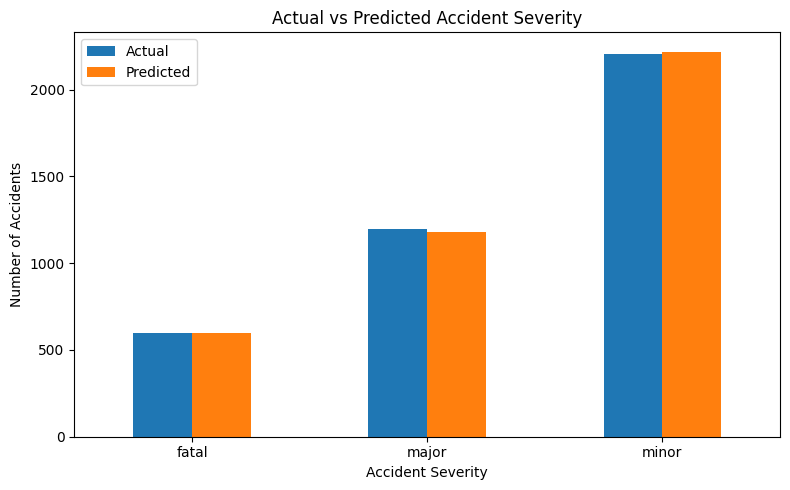

In [ ]:
# Step 61 — Actual vs Predicted Severity

actual_counts = y_test.value_counts().sort_index()
predicted_counts = pd.Series(best_predictions).value_counts().sort_index()

comparison_counts = pd.DataFrame({
    'Actual': actual_counts,
    'Predicted': predicted_counts
}).fillna(0)

print(comparison_counts)
comparison_counts.plot(
    kind='bar',
    figsize=(8, 5)
)

plt.title('Actual vs Predicted Accident Severity')
plt.xlabel('Accident Severity')
plt.ylabel('Number of Accidents')
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

In [ ]:
# Step 63 — Feature Importance Table

feature_table = feature_importance.head(10).reset_index()

feature_table.columns = [
    'Feature',
    'Importance'
]

feature_table['Importance'] = (
    feature_table['Importance'] * 100
).round(2)

print("Top 10 Important Features:")
print(feature_table)

Top 10 Important Features:
                  Feature  Importance
0              risk_score       16.41
1              casualties       10.19
2                latitude        7.98
3               longitude        7.87
4             temperature        6.72
5                    hour        6.41
6       vehicles_involved        5.11
7                   lanes        4.16
8     traffic_density_low        3.32
9  traffic_density_medium        2.99


<Figure size 1000x600 with 0 Axes>

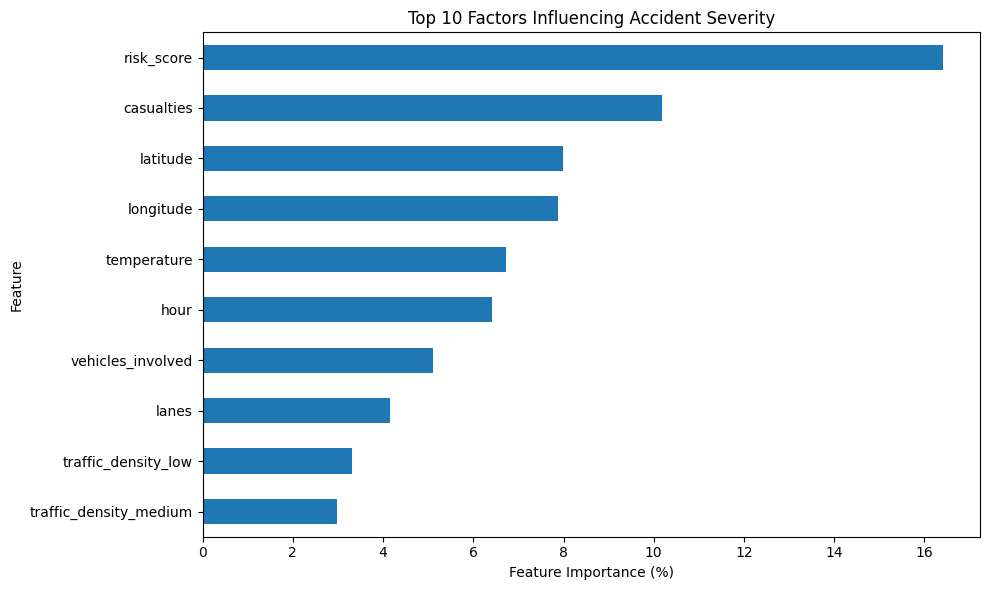

In [ ]:
plt.figure(figsize=(10, 6))

feature_table.sort_values(
    'Importance'
).plot(
    x='Feature',
    y='Importance',
    kind='barh',
    legend=False,
    figsize=(10, 6)
)

plt.title('Top 10 Factors Influencing Accident Severity')
plt.xlabel('Feature Importance (%)')
plt.ylabel('Feature')

plt.tight_layout()
plt.show()

In [ ]:
# Save model comparison
comparison.to_csv(
    'final_model_comparison.csv',
    index=False
)

# Save feature importance
feature_table.to_csv(
    'final_feature_importance.csv',
    index=False
)

print("Final analysis files saved successfully.")

Final analysis files saved successfully.


In [ ]:
print("=" * 50)
print("ROAD ACCIDENT DATA ANALYSIS")
print("FINAL MACHINE LEARNING SUMMARY")
print("=" * 50)

print("\nBest Model:", best_model_name)
print("Accuracy:", best_accuracy, "%")
print(
    "F1-Score:",
    comparison.loc[
        comparison['Model'] == best_model_name,
        'F1-Score'
    ].values[0],
    "%"
)

print("\nTop 10 Important Features:")
print(feature_table)

ROAD ACCIDENT DATA ANALYSIS
FINAL MACHINE LEARNING SUMMARY

Best Model: Decision Tree
Accuracy: 60.55 %
F1-Score: 60.48 %

Top 10 Important Features:
                  Feature  Importance
0              risk_score       16.41
1              casualties       10.19
2                latitude        7.98
3               longitude        7.87
4             temperature        6.72
5                    hour        6.41
6       vehicles_involved        5.11
7                   lanes        4.16
8     traffic_density_low        3.32
9  traffic_density_medium        2.99


In [ ]:
print("Total Missing Values:",
      df.isnull().sum().sum())
print("Dataset Shape:", df.shape)

print("\nDataset Information:")
df.info()

Total Missing Values: 0
Dataset Shape: (20000, 23)

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 23 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   accident_id        20000 non-null  int64  
 1   city               20000 non-null  object 
 2   state              20000 non-null  object 
 3   latitude           20000 non-null  float64
 4   longitude          20000 non-null  float64
 5   date               20000 non-null  object 
 6   time               20000 non-null  object 
 7   hour               20000 non-null  int64  
 8   day_of_week        20000 non-null  object 
 9   is_weekend         20000 non-null  int64  
 10  road_type          20000 non-null  object 
 11  lanes              20000 non-null  int64  
 12  traffic_signal     20000 non-null  int64  
 13  weather            20000 non-null  object 
 14  visibility         20000 non-null  object 
 1

In [ ]:
severity_distribution = df['accident_severity'].value_counts()

print("Accident Severity Distribution:")
print(severity_distribution)

print("\nPercentage Distribution:")
print(
    (severity_distribution / len(df) * 100).round(2)
)

Accident Severity Distribution:
accident_severity
minor    11025
major     5988
fatal     2987
Name: count, dtype: int64

Percentage Distribution:
accident_severity
minor    55.12
major    29.94
fatal    14.94
Name: count, dtype: float64


In [ ]:
final_evaluation = comparison.copy()

print("FINAL EVALUATION TABLE")
print("=" * 70)
print(final_evaluation.to_string(index=False))

FINAL EVALUATION TABLE
              Model  Accuracy  Precision  Recall  F1-Score
Logistic Regression     57.38      60.69   57.38     58.29
      Decision Tree     60.55      60.42   60.55     60.48
      Random Forest     68.23      61.32   68.23     59.38


In [ ]:
best_report = classification_report(
    y_test,
    best_predictions,
    output_dict=True
)

class_performance = pd.DataFrame(best_report).transpose()

print("PER-CLASS PERFORMANCE")
print(class_performance)

PER-CLASS PERFORMANCE
              precision    recall  f1-score    support
fatal          0.993311  0.994975  0.994142   597.0000
major          0.340948  0.336394  0.338655  1198.0000
minor          0.641892  0.646259  0.644068  2205.0000
accuracy       0.605500  0.605500  0.605500     0.6055
macro avg      0.658717  0.659209  0.658955  4000.0000
weighted avg   0.604208  0.605500  0.604845  4000.0000


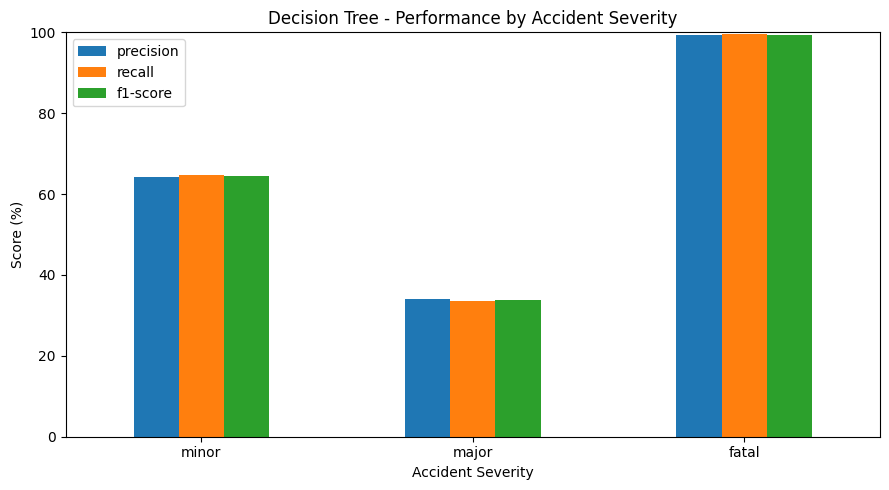

In [ ]:
class_metrics = class_performance.loc[
    ['minor', 'major', 'fatal'],
    ['precision', 'recall', 'f1-score']
] * 100

class_metrics.plot(
    kind='bar',
    figsize=(9, 5)
)

plt.title(f'{best_model_name} - Performance by Accident Severity')
plt.xlabel('Accident Severity')
plt.ylabel('Score (%)')
plt.ylim(0, 100)
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

In [ ]:
import joblib

joblib.dump(
    best_model,
    'accident_severity_model.pkl'
)

print("Best model saved successfully.")

Best model saved successfully.


In [ ]:
joblib.dump(
    X.columns.tolist(),
    'accident_model_features.pkl'
)

print("Feature list saved successfully.")

Feature list saved successfully.


In [ ]:
print("=" * 60)
print("ROAD ACCIDENT DATA ANALYSIS AND SEVERITY PREDICTION")
print("=" * 60)

print("\nDataset:")
print("Total Records:", len(df))
print("Total Features:", df.shape[1])

print("\nMissing Values:")
print(df.isnull().sum().sum())

print("\nSeverity Distribution:")
print(df['accident_severity'].value_counts())

print("\nBest Model:")
print(best_model_name)

print("\nBest Model Accuracy:")
print(str(best_accuracy) + "%")

print("\nBest Model F1-Score:")
print(
    str(
        comparison.loc[
            comparison['Model'] == best_model_name,
            'F1-Score'
        ].values[0]
    ) + "%"
)

print("\nTop 10 Important Features:")
print(feature_table.to_string(index=False))

ROAD ACCIDENT DATA ANALYSIS AND SEVERITY PREDICTION

Dataset:
Total Records: 20000
Total Features: 23

Missing Values:
0

Severity Distribution:
accident_severity
minor    11025
major     5988
fatal     2987
Name: count, dtype: int64

Best Model:
Decision Tree

Best Model Accuracy:
60.55%

Best Model F1-Score:
60.48%

Top 10 Important Features:
               Feature  Importance
            risk_score       16.41
            casualties       10.19
              latitude        7.98
             longitude        7.87
           temperature        6.72
                  hour        6.41
     vehicles_involved        5.11
                 lanes        4.16
   traffic_density_low        3.32
traffic_density_medium        2.99


In [ ]:
!pip install -q plotly ipywidgets

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 45.1 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import numpy as np
import plotly.express as px
import plotly.graph_objects as go

from IPython.display import display, HTML

In [ ]:
display(HTML("""
<div style="
    background: linear-gradient(90deg, #1f4e79, #2e75b6);
    padding: 25px;
    border-radius: 12px;
    color: white;
    text-align: center;
">
    <h1>🚗 Road Accident Analysis & Severity Prediction</h1>
    <p>Interactive Data Science Dashboard</p>
</div>
"""))

In [ ]:
total_accidents = len(df)

minor_count = (df['accident_severity'] == 'minor').sum()
major_count = (df['accident_severity'] == 'major').sum()
fatal_count = (df['accident_severity'] == 'fatal').sum()

display(HTML(f"""
<div style="display:flex; gap:15px; margin-top:20px;">

<div style="flex:1; padding:20px; background:#e8f1f8;
            border-radius:10px; text-align:center;">
<h3>Total Accidents</h3>
<h2>{total_accidents:,}</h2>
</div>

<div style="flex:1; padding:20px; background:#e8f1f8;
            border-radius:10px; text-align:center;">
<h3>Minor</h3>
<h2>{minor_count:,}</h2>
<p>55.12%</p>
</div>

<div style="flex:1; padding:20px; background:#e8f1f8;
            border-radius:10px; text-align:center;">
<h3>Major</h3>
<h2>{major_count:,}</h2>
<p>29.94%</p>
</div>

<div style="flex:1; padding:20px; background:#e8f1f8;
            border-radius:10px; text-align:center;">
<h3>Fatal</h3>
<h2>{fatal_count:,}</h2>
<p>14.94%</p>
</div>

</div>
"""))

In [ ]:
severity_counts = (
    df['accident_severity']
    .value_counts()
    .reset_index()
)

severity_counts.columns = ['Severity', 'Count']

fig = px.pie(
    severity_counts,
    names='Severity',
    values='Count',
    hole=0.4,
    title='Accident Severity Distribution'
)

fig.update_layout(
    width=800,
    height=500
)

fig.show()

In [ ]:
hour_data = (
    df.groupby('hour')
    .size()
    .reset_index(name='Accidents')
)

fig = px.line(
    hour_data,
    x='hour',
    y='Accidents',
    markers=True,
    title='Accidents by Hour'
)

fig.update_layout(
    xaxis_title='Hour of Day',
    yaxis_title='Number of Accidents'
)

fig.show()

In [ ]:
traffic_data = pd.crosstab(
    df['traffic_density'],
    df['accident_severity']
).reset_index()

fig = px.bar(
    traffic_data,
    x='traffic_density',
    y=['minor', 'major', 'fatal'],
    barmode='group',
    title='Accident Severity by Traffic Density'
)

fig.show()

In [ ]:
fig = px.histogram(
    df,
    x='temperature',
    color='accident_severity',
    nbins=30,
    title='Accident Severity Distribution by Temperature'
)

fig.update_layout(
    xaxis_title='Temperature',
    yaxis_title='Number of Accidents'
)

fig.show()

In [ ]:
vehicle_data = (
    df.groupby('vehicles_involved')
    .size()
    .reset_index(name='Accidents')
)

fig = px.bar(
    vehicle_data,
    x='vehicles_involved',
    y='Accidents',
    title='Accidents by Number of Vehicles Involved'
)

fig.show()

In [ ]:
display(HTML(f"""
<div style="
    background:#f5f5f5;
    padding:25px;
    border-radius:12px;
    margin-top:20px;
">

<h2>🤖 Machine Learning Results</h2>

<table style="width:100%; text-align:center; border-collapse:collapse;">
<tr>
<th style="padding:12px;">Best Model</th>
<th style="padding:12px;">Accuracy</th>
<th style="padding:12px;">F1-Score</th>
</tr>

<tr>
<td style="padding:12px;"><b>Decision Tree</b></td>
<td style="padding:12px;"><b>60.55%</b></td>
<td style="padding:12px;"><b>60.48%</b></td>
</tr>

</table>

</div>
"""))

Best Model,Accuracy,F1-Score
Decision Tree,60.55%,60.48%


In [ ]:
feature_data = pd.DataFrame({
    'Feature': [
        'risk_score',
        'casualties',
        'latitude',
        'longitude',
        'temperature',
        'hour',
        'vehicles_involved',
        'lanes',
        'traffic_density_low',
        'traffic_density_medium'
    ],
    'Importance': [
        16.41,
        10.19,
        7.98,
        7.87,
        6.72,
        6.41,
        5.11,
        4.16,
        3.32,
        2.99
    ]
})

fig = px.bar(
    feature_data.sort_values('Importance'),
    x='Importance',
    y='Feature',
    orientation='h',
    title='Top 10 Important Features'
)

fig.update_layout(
    xaxis_title='Importance (%)',
    yaxis_title='Feature'
)

fig.show()

In [ ]:
fig = px.scatter_map(
    df.sample(min(5000, len(df))),
    lat='latitude',
    lon='longitude',
    color='accident_severity',
    zoom=5,
    height=600,
    title='Geographical Distribution of Accidents'
)

fig.show()
fig = px.scatter_mapbox(
    df.sample(min(5000, len(df))),
    lat='latitude',
    lon='longitude',
    color='accident_severity',
    zoom=5,
    height=600
)

fig.update_layout(
    mapbox_style="open-street-map"
)

fig.show()